29 Hz → 200000 samples
32 Hz → 200000 samples
38 Hz → 200000 samples
44 Hz → 200000 samples
49 Hz → 200000 samples
56 Hz → 200000 samples


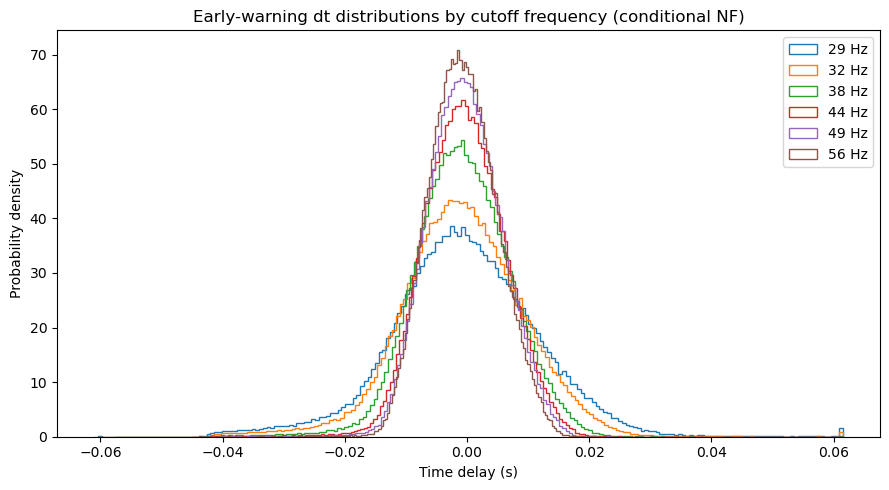

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ml_stat_universal import MLStatistic

MODEL_H5 = "../../Files/EW/PHASE_TIME_AMP_L1H1_EW.h5"
FREQS = [29, 32, 38, 44, 49, 56]
N_SAMPLES = 200000
NBINS = 200
DENSITY = True
def robust_sample(model, n_samples, conditional, chunk=20000, max_retries=10):
    """Sample in chunks; if a chunk throws InputOutsideDomain, retry that chunk."""
    out = []
    i = 0
    while i < n_samples:
        m = min(chunk, n_samples - i)
        cond_chunk = conditional[i:i+m] if conditional is not None else None

        for _ in range(max_retries):
            try:
                s = model.sample(m, conditional=cond_chunk)
                out.append(s)
                i += m
                break
            except Exception as e:
                last = e
        else:
            raise RuntimeError(f"Failed to sample chunk starting at {i} after {max_retries} retries") from last

    return np.vstack(out)
ml = MLStatistic.from_file(MODEL_H5)

dt_idx = 0

plt.figure(figsize=(9, 5))

for fr in FREQS:
    cond = np.full((N_SAMPLES, 1), float(fr), dtype=np.float64)
    samples = robust_sample(ml.model, N_SAMPLES, cond, chunk=20000)

    dt = samples[:, dt_idx].astype(float)
    dt = dt[np.isfinite(dt)]

    plt.hist(dt, bins=NBINS, density=DENSITY, histtype="step", label=f"{fr} Hz")
    print(f"{fr} Hz → {dt.size} samples")

plt.xlabel("Time delay (s)")
plt.ylabel("Probability density" if DENSITY else "Counts")
plt.title("Early-warning dt distributions by cutoff frequency (conditional NF)")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from ml_stat_universal import MLStatistic

MODEL_H5 = "../../Files/EW/PHASE_TIME_AMP_L1H1_EW.h5"

# Load model
ml = MLStatistic.from_file(MODEL_H5)

# Point where we want the density
x = np.array([[0.0, 3.14, 0.0]], dtype=np.float64)

# Conditioning value (29 Hz)
cond = np.array([[56.0]], dtype=np.float64)

# Evaluate
logp = ml.log_prob(x, conditional=cond)[0]
p = np.exp(logp)

print("log probability =", logp)
print("probability density =", p)

log probability = 4.44519
probability density = 85.216064
